# Comparison Model

Compares current (realtime) metrics with previous month and previous year.

- CSV file: final_dataset_for_electiccar_2.csv
- If no date column exists, a synthetic timeline is created for demo.

Run cells top to bottom, then use the controls.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import panel as pn
import matplotlib.pyplot as plt

pn.extension(sizing_mode="stretch_width")

DATA_PATH = Path("final_dataset_for_electiccar_2.csv")

df_raw = pd.read_csv(DATA_PATH)

rename_map = {
    "driver id": "driver_id",
    "car id": "car_id",
    "drive name": "drive_name",
    "city": "city",
    "vechicle type": "vehicle_type",
    "vechicle age": "vehicle_age",
    "battery capacity(kw)": "battery_capacity_kw",
    "total km driven": "total_km_driven",
    "current charge percentage": "current_charge_percentage",
    "estimated rangekm": "estimated_rangekm",
    "batery health": "battery_health",
    "vechicle-status": "vehicle_status",
    "average energy per km kwh": "average_energy_per_km_kwh",
    "charging cost": "charging_cost",
    "total maintanace cost": "total_maintenance_cost",
    "max speed": "max_speed",
    "gross revenue": "gross_revenue",
    "driver earnings": "driver_earnings"
}

df = df_raw.rename(columns=rename_map)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.head()

,driver_id,car_id,drive_name,city,vehicle_type,vehicle_age,battery_capacity_kw,total_km_driven,current_charge_percentage,estimated_rangekm,battery_health,vehicle_status,average_energy_per_km_kwh,charging_cost,total_maintenance_cost,max_speed,gross_revenue,driver_earnings
0,1,100001,Driver_1,Chennai,Sedan,6.1,40,59686.6,76.3,175.4,96.8,Active,0.174,3157.22,6227.34,120,429016.47,175021.90
1,2,100002,Driver_2,Bangalore,Mini EV,2.2,75,73156.7,88.2,365.5,74.8,Maintenance,0.181,2031.13,32756.08,140,126657.71,65099.30
2,3,100003,Driver_3,Hyderabad,Hatchback,5.0,30,183784.3,58.3,88.3,81.4,Inactive,0.198,1819.30,39736.81,140,483014.11,295301.09
3,4,100004,Driver_4,Chennai,SUV,6.3,30,214552.8,88.0,176.0,83.6,Maintenance,0.150,1231.94,28515.04,100,506848.25,228761.70
4,5,100005,Driver_5,Bangalore,SUV,4.0,50,247433.2,67.6,204.8,90.5,Active,0.165,1530.72,12442.59,140,99641.45,67152.44


In [2]:
possible_date_cols = ["record_date", "date", "timestamp", "created_at"]
date_col = next((c for c in possible_date_cols if c in df.columns), None)

df = df.copy()
if date_col is None:
    df["record_date"] = pd.date_range(
        end=pd.Timestamp.today().normalize(),
        periods=len(df),
        freq="D"
    )
    date_col = "record_date"
else:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

metrics = ["gross_revenue", "total_km_driven", "driver_earnings"]
available_metrics = [m for m in metrics if m in df.columns]

monthly = (
    df.set_index(date_col)
    .sort_index()[available_metrics]
    .resample("M")
    .sum()
)

def compare_metric(metric, current_value=None):
    if metric not in monthly.columns:
        return None

    current_period = monthly.index.max()
    if current_period is pd.NaT:
        return None

    current_month_value = monthly.loc[current_period, metric]
    current_value = current_month_value if current_value is None else current_value

    prev_month_value = monthly.shift(1).loc[current_period, metric]
    prev_year_value = monthly.shift(12).loc[current_period, metric]

    def pct_change(current, previous):
        if pd.isna(previous) or previous == 0:
            return np.nan
        return (current - previous) / previous * 100.0

    return {
        "current_value": current_value,
        "prev_month_value": prev_month_value,
        "prev_year_value": prev_year_value,
        "prev_month_change_pct": pct_change(current_value, prev_month_value),
        "prev_year_change_pct": pct_change(current_value, prev_year_value),
    }

def metric_plot(metric):
    fig, ax = plt.subplots(figsize=(8, 4))
    data = monthly[metric].tail(18)
    data.plot(ax=ax, marker="o")
    ax.set_title(f"Last 18 Months: {metric}")
    ax.set_xlabel("Month")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

C:\Users\Admin\AppData\Local\Temp\ipykernel_21228\1980750273.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


In [3]:
metric_select = pn.widgets.Select(
    name="Metric",
    options=available_metrics or ["gross_revenue"]
)
use_input = pn.widgets.Checkbox(name="Use manual current value", value=False)
current_input = pn.widgets.FloatInput(name="Current value", value=0.0, step=100.0)
compare_button = pn.widgets.Button(name="Run comparison", button_type="primary")

result_pane = pn.pane.Markdown("Ready.")
plot_pane = pn.pane.Matplotlib(height=300)

def on_compare_click(event):
    metric = metric_select.value
    current_value = current_input.value if use_input.value else None
    result = compare_metric(metric, current_value=current_value)

    if result is None:
        result_pane.object = "Metric not available in dataset."
        return

    result_pane.object = (
        f"**Current value:** {result['current_value']:.2f}\n"
        f"**Previous month:** {result['prev_month_value']:.2f}\n"
        f"**Previous year (same month):** {result['prev_year_value']:.2f}\n"
        f"**Change vs prev month:** {result['prev_month_change_pct']:.2f}%\n"
        f"**Change vs prev year:** {result['prev_year_change_pct']:.2f}%"
    )

    plot_pane.object = metric_plot(metric)

compare_button.on_click(on_compare_click)

dashboard = pn.Column(
    pn.pane.Markdown("## Month and Year Comparison"),
    pn.Row(metric_select, use_input, current_input, compare_button),
    result_pane,
    plot_pane,
    sizing_mode="stretch_width"
)

dashboard

BokehModel(combine_events=True, render_bundle={'docs_json': {'3d431e66-2cfb-4c13-9a1d-d3272546d825': {'version…

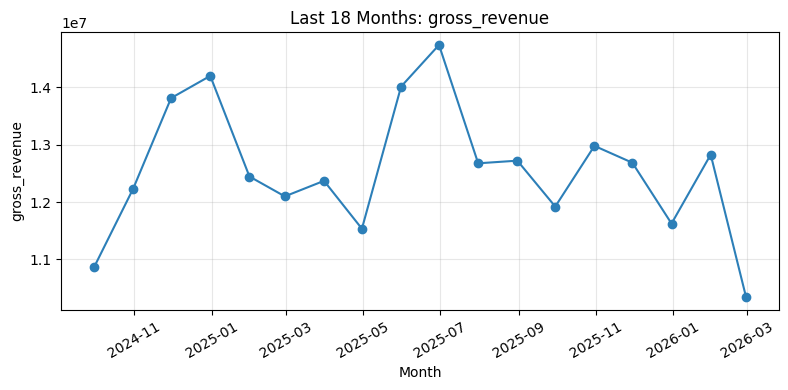

In [4]:
import matplotlib.pyplot as plt

metric = available_metrics[0] if available_metrics else None

if metric is None:
    print("No metric available to plot.")
else:
    series = monthly[metric].tail(18)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(series.index, series.values, marker="o", color="#2c7fb8")
    ax.set_title(f"Last 18 Months: {metric}")
    ax.set_xlabel("Month")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()